# Problem

**10×10 Gridworld**

**Layout (row-major indices)**

Legend: **S** start, **G** goal (terminal), **P** pit (terminal), **#** wall, **.** empty

```
r\c  0 1 2 3 4 5 6 7 8 9
0    S . . . # . . . . .
1    . # . . # . . # P .
2    . # # . . . . # . .
3    . . P . # . . # . .
4    # . # # # # # # . #
5    . . . . # . . P . .
6    . P # . # . # . . .
7    . . # . . P # . . .
8    . . # . # . # # . .
9    . . . . # . . . . G
```

**State space**

$$
\mathcal{X}={0,1,\dots,99},\quad x=10r+c
$$

* **Goal (absorbing):** $x_G=99$
* **Pits (absorbing):**
  $
  \mathcal{X}_{\text{pit}}={18,32,57,61,75,88}
  $
* **Walls (impassable):**
  $
  \mathcal{X}_{\text{wall}}={4,11,14,17,21,22,27,34,37,40,42,43,44,45,46,47,49,54,62,64,66,72,76,82,84,86,87,94}
  $

Terminal set:
$
\mathcal{T}={99}\cup \mathcal{X}_{\text{pit}}
$

**Action space**

$$
\mathcal{A}={0,1,2,3}
$$
where (0=) Up, (1=) Down, (2=) Left, (3=) Right.

**Transition dynamics (deterministic)**

Let $x\mapsto(r,c)$ by $r=\lfloor x/10\rfloor,\ c=x\bmod 10$.

* If $x\in\mathcal{T}$, then $\text{next\_state}(x,a)=x$ $absorbing$.
* Otherwise, compute the intended neighbor $(r',c')$ from action $a$.
* If $(r',c')$ is outside the grid, **stay**.
* Let $x'=10r'+c'$. If $x'\in\mathcal{X}_{\text{wall}}$, **stay**.

Transition matrix shape:
$$
P\in\mathbb{R}^{(|\mathcal{X}||\mathcal{A}|)\times|\mathcal{X}|}=\mathbb{R}^{400\times 100},
$$
with
$$
P[(x,a),x']=1 \iff x'=\text{next\_state}(x,a)
$$

**Reward model (standard step cost + terminal outcomes)**

Reward based on the **next state**:
$$
r(x,a)=
\begin{cases}
+1 & \text{if } \text{next\_state}(x,a)=99,\
-5 & \text{if } \text{next\_state}(x,a)\in \mathcal{X}_{\text{pit}},\
-0.1 & \text{otherwise.}
\end{cases}
$$

**Initial state**

$$
x_0=0.
$$

In [1]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import random
import torch
import pandas as pd
import sys
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

import sys
sys.path.insert(0, '/shared/home/mauro.diaz/work/FOGAS')

# This starts from the current working directory
# and goes up until it finds the 'fogas_torch' folder or '.git'
def find_root(current_path, marker="fogas_torch"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())
print(f"Project root found at: {PROJECT_ROOT}")
# Now define the dataset path
DATASET_PATH = PROJECT_ROOT / "datasets" / "10grid_wall.csv"
print(f"Loading dataset from: {DATASET_PATH}")

from fogas_torch import PolicySolver, EnvDataCollector
from fogas_torch.algorithm import (
    FOGASSolverVectorized,
    FOGASOracleSolverVectorized,
    FOGASHyperOptimizer,
    FOGASEvaluator,
    FOGASDataset,
)
from fogas_torch.dataset_collection import DatasetAnalyzer
from fogas_torch.fqi.fqi_solver import FQISolver
from fogas_torch.fqi.fqi_evaluator import FQIEvaluator

seed = 42
np.random.seed(seed) # Add this
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Project root found at: /shared/home/mauro.diaz/work/FOGAS
Loading dataset from: /shared/home/mauro.diaz/work/FOGAS/datasets/10grid_wall.csv
Using device: cpu


# Tabular Features

In [4]:
# ===== 10x10 Four-Rooms Grid =====

states  = torch.arange(100, dtype=torch.int64)
actions = torch.arange(4, dtype=torch.int64)
N = len(states)     # 100
A = len(actions)    # 4
gamma = 0.9

x_0 = 0  # fixed initial state

goal = 99  # absorbing terminal state

# pits (absorbing terminal states)
pits = {18, 32, 57, 61, 75}

# walls (impassable)
walls = {
    4, 11, 14, 17, 21, 22, 27, 34, 37,
    40, 42, 43, 44, 45, 46, 47, 49,
    54, 62, 64, 66, 72, 76, 82, 84, 86, 87, 94
}

# ---------- Tabular features ----------
def phi(x, a):
    vec = torch.zeros(N * A, dtype=torch.float64)
    vec[int(x) * A + int(a)] = 1.0
    return vec

# ---------- Reward weights (tabular) ----------
step_cost = -0.1
goal_reward = 1.0
pit_reward  = -5.0

omega = torch.full((N * A,), step_cost, dtype=torch.float64)

# override terminal rewards (all actions in terminal states)
omega[goal * A : goal * A + A] = goal_reward
for p in pits:
    omega[p * A : p * A + A] = pit_reward

# ---------- Helpers: index <-> (row, col) ----------
def to_rc(s):  return divmod(s, 10)
def to_s(r, c): return r * 10 + c

# ---------- Dynamics ----------
def next_state(s, a):
    # absorbing terminals
    if s == goal or s in pits:
        return s

    r, c = to_rc(s)

    if a == 0:      # Up
        r2, c2 = max(0, r - 1), c
    elif a == 1:    # Down
        r2, c2 = min(9, r + 1), c
    elif a == 2:    # Left
        r2, c2 = r, max(0, c - 1)
    elif a == 3:    # Right
        r2, c2 = r, min(9, c + 1)
    else:
        raise ValueError("Invalid action")

    sp = to_s(r2, c2)

    # wall blocks transition
    if sp in walls:
        return s

    return sp

# ---------- Backward feature map psi(x') ----------
def psi(xp):
    v = torch.zeros(N * A, dtype=torch.float64)
    for x in states:
        for a in actions:
            if next_state(int(x), int(a)) == xp:
                v[int(x) * A + int(a)] = 1.0
    return v

# ---------- Build solver ----------
mdp = PolicySolver(
    states=states,
    actions=actions,
    phi=phi,
    omega=omega,
    gamma=gamma,
    x0=x_0,
    psi=psi
)


## Oracle

In [19]:
solver = FOGASOracleSolverVectorized(
    mdp=mdp, 
    cov_matrix="identity", 
    print_params=True, 
    T=1000,
    device=device,
    seed=seed
)
evaluator = FOGASEvaluator(solver)
optimizer = FOGASHyperOptimizer(solver=solver,metric_callable=evaluator.get_metric("reward"), seed=seed)



================ FOGAS PARAMETER SUMMARY ================

Basic Information
-----------------
Dataset size n:           10000000.0
Feature norm bound R:     1.0000
Num states N:             100
Num actions A:            4
Feature dim d:            400
Discount γ:               0.9
Confidence δ:             0.05

Theoretical Quantities
----------------------
T_min (theoretical):      9255128.526390366
T (iterations):                1000   (overridden → 1000)

FOGAS Hyperparameters
---------------------
alpha:                        0.000263
rho:                            66.292053
eta:                            0.000002
D_theta:                    63.245553
beta (ridge):             0.000003
D_pi (derived):           16.651092




We do an hyperparameter optimization because is not clear how will work the Oracle in a big dimensional problem.


=== FOGAS Hyperparameter Optimization ===
[Theory] metric = 0.3761
Order: ('alpha', 'rho', 'eta')

Optimizing alpha
[After alpha*] alpha=4.7512e+00, rho=1.0000e-02, eta=1.5215e-06 | metric = 0.1000

Optimizing rho
[After rho*] alpha=4.7512e+00, rho=1.0000e-02, eta=1.5215e-06 | metric = 0.1000

Optimizing eta
[After eta*] alpha=4.7512e+00, rho=1.0000e-02, eta=3.0000e+00 | metric = 0.0432


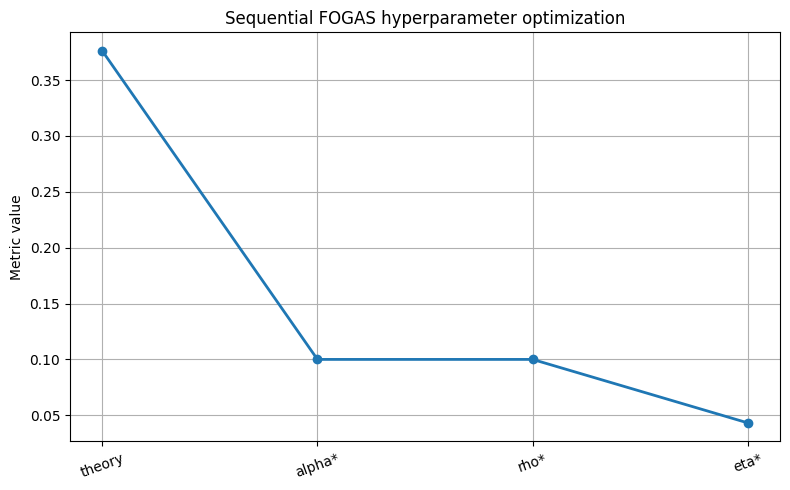

In [20]:
summary = optimizer.optimize_fogas_hyperparameters(
    search_method="random",
    coarse_points=7,
    print_main=True, 
    num_runs=1,
    random_candidates=10,
    order=("alpha", "rho", "eta"),
    bounds_overrides={"alpha" : (1e-2, 5.0), "rho" : (1e-2, 3.0), "eta" : (1e-2, 3.0)}
)

alpha_star = summary["alpha"]
rho_star = summary["rho"]
eta_star = summary["eta"]

In [21]:
solver.run(T = 10000, alpha=alpha_star, eta=eta_star, rho=rho_star, tqdm_print=True)
evaluator.print_policy()

FOGAS Oracle: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:54<00:00, 185.08it/s]

  State 0: π(a=0|s=0) = 0.00  π(a=1|s=0) = 0.41  π(a=2|s=0) = 0.00  π(a=3|s=0) = 0.59  --> best action: 3
  State 1: π(a=0|s=1) = 0.00  π(a=1|s=1) = 0.00  π(a=2|s=1) = 0.00  π(a=3|s=1) = 1.00  --> best action: 3
  State 2: π(a=0|s=2) = 0.00  π(a=1|s=2) = 0.50  π(a=2|s=2) = 0.00  π(a=3|s=2) = 0.50  --> best action: 1
  State 3: π(a=0|s=3) = 0.00  π(a=1|s=3) = 1.00  π(a=2|s=3) = 0.00  π(a=3|s=3) = 0.00  --> best action: 1
  State 4: π(a=0|s=4) = 0.00  π(a=1|s=4) = 0.00  π(a=2|s=4) = 0.00  π(a=3|s=4) = 1.00  --> best action: 3
  State 5: π(a=0|s=5) = 0.00  π(a=1|s=5) = 0.00  π(a=2|s=5) = 0.00  π(a=3|s=5) = 1.00  --> best action: 3
  State 6: π(a=0|s=6) = 0.00  π(a=1|s=6) = 0.00  π(a=2|s=6) = 0.00  π(a=3|s=6) = 1.00  --> best action: 3
  State 7: π(a=0|s=7) = 0.00  π(a=1|s=7) = 0.00  π(a=2|s=7) = 0.00  π(a=3|s=7) = 1.00  --> best action: 3
  State 8: π(a=0|s=8) = 0.00  π(a=1|s=8) = 0.00  π(a=2|s=8) = 0.00  π(a=3|s=8) = 1.00  --> best action: 3
  State 9: π(a=0|s=9) = 0.00  π(a=1|s=9) = 1.0

Let's do an easy check that the policy achieves the goal in a optimal way:

In [22]:
evaluator.print_optimal_path(goal_state=99)


  OPTIMAL PATH VISUALIZATION - Learned Policy (π_FOGAS)

Initial State: 0
Goal State: 99
Discount Factor (γ): 0.9

----------------------------------------------------------------------

  Step   0 │ State: 0        │ Action: 3       │ Reward:  -0.100 │ → 1
  Step   1 │ State: 1        │ Action: 3       │ Reward:  -0.100 │ → 2
  Step   2 │ State: 2        │ Action: 1       │ Reward:  -0.100 │ → 12
  Step   3 │ State: 12       │ Action: 3       │ Reward:  -0.100 │ → 13
  Step   4 │ State: 13       │ Action: 1       │ Reward:  -0.100 │ → 23
  Step   5 │ State: 23       │ Action: 3       │ Reward:  -0.100 │ → 24
  Step   6 │ State: 24       │ Action: 3       │ Reward:  -0.100 │ → 25
  Step   7 │ State: 25       │ Action: 0       │ Reward:  -0.100 │ → 15
  Step   8 │ State: 15       │ Action: 0       │ Reward:  -0.100 │ → 5
  Step   9 │ State: 5        │ Action: 3       │ Reward:  -0.100 │ → 6
  Step  10 │ State: 6        │ Action: 3       │ Reward:  -0.100 │ → 7
  Step  11 │ State: 7    

## Empirical

### Dataset Collection

In [3]:
# Initialize the collector with these options
collector = EnvDataCollector(
    mdp=mdp,
    env_name="10grid_wall",
    reset_probs={'custom': 1.0},
    max_steps=50,
    seed=seed
)

In [ ]:
# Create an epsilon-greedy pi_star (30% optimal, 70% random)
epsilon_policy = (mdp.pi_star, 0.3)

# Use it in your mixed collection as before
collector.collect_mixed_dataset(
    policies=[epsilon_policy, "random"],  
    proportions=[0.8, 0.2],
    n_steps=8000,
    episode_based=True,                   
    save_path=str(DATASET_PATH),
    verbose=True
)


  MIXED DATASET COLLECTION SUMMARY (TORCH)
Total transitions: 8000
Total episodes: 242
Mode: Episode-based

Policy Distribution:
  Policy 0:  6047 steps (75.6%) | Target: 80.0% | Episodes: 194
  Policy 1:  1953 steps (24.4%) | Target: 20.0% | Episodes: 49

✅ Mixed dataset saved to: /shared/home/mauro.diaz/work/FOGAS/datasets/10grid_wall.csv


,episode,step,state,action,reward,next_state,policy_id
0,0,0,0,0,-0.1,0,0
1,0,1,0,3,-0.1,1,0
2,0,2,1,3,-0.1,2,0
3,0,3,2,1,-0.1,12,0
4,0,4,12,3,-0.1,13,0
...,...,...,...,...,...,...,...
7995,242,9,3,3,-0.1,3,1
7996,242,10,3,2,-0.1,2,1
7997,242,11,2,0,-0.1,2,1
7998,242,12,2,0,-0.1,2,1


In [5]:
analyzer = DatasetAnalyzer(DATASET_PATH)

analyzer.summary()

Dataset Analysis Summary
Source: /shared/home/mauro.diaz/work/FOGAS/datasets/10grid_wall.csv
Total transitions: 8,000
Unique (state, action) pairs: 195
Unique states visited: 53
Unique actions taken: 4
--------------------------------------------------
Pair Frequency Statistics:
  Min count:    1
  Max count:    300
  Mean count:   41.03
  Std count:    62.54
  Median count: 17.0


### Solving it

In [6]:
solver_e = FOGASSolverVectorized(
    mdp=mdp,
    csv_path=str(DATASET_PATH),
    device=device,
    seed=seed)
evaluator_e = FOGASEvaluator(solver_e)
optimizer_e = FOGASHyperOptimizer(solver=solver_e,metric_callable=evaluator_e.get_metric("reward"), seed=seed)

In [7]:
# Run solver with best alpha and fixed rho, eta
solver_e.run(alpha=0.001 / 2, eta=0.0002, rho=0.05, tqdm_print=True, T=12000)
evaluator_e.print_policy()

FOGAS: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 12000/12000 [00:07<00:00, 1709.18it/s]


  State 0: π(a=0|s=0) = 0.13  π(a=1|s=0) = 0.17  π(a=2|s=0) = 0.12  π(a=3|s=0) = 0.58  --> best action: 3
  State 1: π(a=0|s=1) = 0.13  π(a=1|s=1) = 0.14  π(a=2|s=1) = 0.05  π(a=3|s=1) = 0.68  --> best action: 3
  State 2: π(a=0|s=2) = 0.14  π(a=1|s=2) = 0.63  π(a=2|s=2) = 0.06  π(a=3|s=2) = 0.18  --> best action: 1
  State 3: π(a=0|s=3) = 0.25  π(a=1|s=3) = 0.46  π(a=2|s=3) = 0.09  π(a=3|s=3) = 0.20  --> best action: 1
  State 4: π(a=0|s=4) = 0.25  π(a=1|s=4) = 0.25  π(a=2|s=4) = 0.25  π(a=3|s=4) = 0.25  --> best action: 0
  State 5: π(a=0|s=5) = 0.15  π(a=1|s=5) = 0.07  π(a=2|s=5) = 0.13  π(a=3|s=5) = 0.65  --> best action: 3
  State 6: π(a=0|s=6) = 0.11  π(a=1|s=6) = 0.07  π(a=2|s=6) = 0.07  π(a=3|s=6) = 0.75  --> best action: 3
  State 7: π(a=0|s=7) = 0.13  π(a=1|s=7) = 0.09  π(a=2|s=7) = 0.06  π(a=3|s=7) = 0.73  --> best action: 3
  State 8: π(a=0|s=8) = 0.11  π(a=1|s=8) = 0.03  π(a=2|s=8) = 0.05  π(a=3|s=8) = 0.81  --> best action: 3
  State 9: π(a=0|s=9) = 0.10  π(a=1|s=9) = 0.7

In [8]:
evaluator_e.print_optimal_path(goal_state=99)


  OPTIMAL PATH VISUALIZATION - Learned Policy (π_FOGAS)

Initial State: 0
Goal State: 99
Discount Factor (γ): 0.9

----------------------------------------------------------------------

  Step   0 │ State: 0        │ Action: 3       │ Reward:  -0.100 │ → 1
  Step   1 │ State: 1        │ Action: 3       │ Reward:  -0.100 │ → 2
  Step   2 │ State: 2        │ Action: 1       │ Reward:  -0.100 │ → 12
  Step   3 │ State: 12       │ Action: 3       │ Reward:  -0.100 │ → 13
  Step   4 │ State: 13       │ Action: 1       │ Reward:  -0.100 │ → 23
  Step   5 │ State: 23       │ Action: 3       │ Reward:  -0.100 │ → 24
  Step   6 │ State: 24       │ Action: 3       │ Reward:  -0.100 │ → 25
  Step   7 │ State: 25       │ Action: 0       │ Reward:  -0.100 │ → 15
  Step   8 │ State: 15       │ Action: 3       │ Reward:  -0.100 │ → 16
  Step   9 │ State: 16       │ Action: 0       │ Reward:  -0.100 │ → 6
  Step  10 │ State: 6        │ Action: 3       │ Reward:  -0.100 │ → 7
  Step  11 │ State: 7   

**Stabilizing the algorithm:** After data analysis, the dataset doesnt reach a lot of states so covariance inverse is unstable. Augmenting $\beta$ helps.

- More $\beta$ = more bias / less sensitivity to uncovered directions.

- If the uncovered directions actually matter for optimality, too-large $\beta$ can make the algorithm look stable while converging to a worse solution.

In this case, we can see that $β$ = 0.0001 is a good choice.

In [9]:
solver_e1 = FOGASSolverVectorized(
    mdp=mdp,
    csv_path=str(DATASET_PATH),
    device=device,
    beta=1e-4,
    seed=seed)
evaluator_e1 = FOGASEvaluator(solver_e1)
optimizer_e1 = FOGASHyperOptimizer(solver=solver_e1,metric_callable=evaluator_e1.get_metric("reward"), seed=seed)
# Run solver with best alpha and fixed rho, eta
solver_e1.run(alpha=0.001, eta=0.0002, rho=0.05, tqdm_print=True, T=12000)
evaluator_e1.print_policy()
evaluator_e1.print_optimal_path(goal_state=99)

FOGAS: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 12000/12000 [00:07<00:00, 1708.40it/s]

  State 0: π(a=0|s=0) = 0.10  π(a=1|s=0) = 0.17  π(a=2|s=0) = 0.10  π(a=3|s=0) = 0.63  --> best action: 3
  State 1: π(a=0|s=1) = 0.12  π(a=1|s=1) = 0.14  π(a=2|s=1) = 0.02  π(a=3|s=1) = 0.73  --> best action: 3
  State 2: π(a=0|s=2) = 0.13  π(a=1|s=2) = 0.65  π(a=2|s=2) = 0.03  π(a=3|s=2) = 0.19  --> best action: 1
  State 3: π(a=0|s=3) = 0.25  π(a=1|s=3) = 0.47  π(a=2|s=3) = 0.07  π(a=3|s=3) = 0.20  --> best action: 1
  State 4: π(a=0|s=4) = 0.25  π(a=1|s=4) = 0.25  π(a=2|s=4) = 0.25  π(a=3|s=4) = 0.25  --> best action: 0
  State 5: π(a=0|s=5) = 0.19  π(a=1|s=5) = 0.10  π(a=2|s=5) = 0.17  π(a=3|s=5) = 0.54  --> best action: 3
  State 6: π(a=0|s=6) = 0.10  π(a=1|s=6) = 0.06  π(a=2|s=6) = 0.08  π(a=3|s=6) = 0.76  --> best action: 3
  State 7: π(a=0|s=7) = 0.12  π(a=1|s=7) = 0.09  π(a=2|s=7) = 0.05  π(a=3|s=7) = 0.74  --> best action: 3
  State 8: π(a=0|s=8) = 0.11  π(a=1|s=8) = 0.00  π(a=2|s=8) = 0.06  π(a=3|s=8) = 0.84  --> best action: 3
  State 9: π(a=0|s=9) = 0.10  π(a=1|s=9) = 0.7

## Data Analysis

**What “alignment-based coverage” looks like in this tabular case**

FOGAS’ key coverage term is the **feature coverage ratio**
$$
|\lambda_{\pi^*}|_{\Lambda_n^{-1}}^2
$$
(and this measures how well the dataset covers the comparator policy in feature space). 

With one-hot features, the empirical covariance
$$
\Lambda_n = \beta I + \frac{1}{n}\sum_{i=1}^n \phi_i\phi_i^\top
$$
is **diagonal**, and each diagonal entry corresponds to a particular $(x,a)$:
$$
(\Lambda_n)_{(x,a),(x,a)} = \beta + \frac{N(x,a)}{n}.
$$
(Here $N(x,a)$ is how often $(x,a)$ appears in the dataset.) 

Because it’s diagonal, the coverage ratio becomes:
$$
|\lambda_{\pi^*}|_{\Lambda_n^{-1}}^2 =
\sum_{x,a}\frac{\mu_{\pi^*}(x,a)^2}{\beta + N(x,a)/n}.
$$

So **alignment-based coverage** (in tabular) literally means:

- The dataset counts $N(x,a)$ are large exactly on the $(x,a)$ where $\mu_{\pi^*}(x,a)$ is large.


In [10]:
analyzer = DatasetAnalyzer(DATASET_PATH)

ratio = analyzer.feature_coverage_ratio(
    mdp=mdp,
    beta=1e-4,
    use_optimal_policy=True,
    verbose=True,
    return_details=True,
)


Feature Coverage Ratio Details
------------------------------
  Dataset size (n):         8000
  MDP dims (N, A, d):        (100, 4, 400)
  gamma:                    0.9
  beta (ridge):             0.0001
  policy source:            provided

  Occupancy μ_pi summary:
    sum:                    1
    min / max:              0 / 0.1

  Feature occupancy λ_pi summary:
    ||λ||_2:                0.242197
    ||λ||_1:                1
    max |λ_i|:              0.1

  Empirical covariance Λ_n:
    diag min / mean / max:  0.0001 / 0.0026 / 0.0376
    eig min / max:          0.0001 / 0.0376
    condition number:       376

  Coverage ratio:           65.3694


### Grid search

For each dataset setting—given an exploration level $\epsilon$, an “optimal injection” mixture $\alpha$ (e.g. $\pi_b=(1-\alpha)\pi_\epsilon+\alpha\pi^*$), and a dataset size $n$—these three metrics separate *task success*, *on-data reliability*, and *performance on the truly important (optimal) regions*: 

(1) the **default-start return** $J(\hat\pi;\rho_{\text{start}})=\mathbb{E}_{s_0\sim\rho_{\text{start}}}[V^{\hat\pi}(s_0)]$ tells us whether the learned policy solves the environment from the standard start distribution; 

(2) the **Q optimal gap** $\mathbb{E}_{(s, a) \sim \mu_{\pi^*}}[Q^*(s, a)-Q^{\hat\pi}(s, a)]$ 

and (3) the **V optimal gap** $\mathbb{E}_{s\sim d_{\pi^*}}[V^*(s)-V^{\hat\pi}(s)]$ tells us how good we are on the states that matter under optimal behavior (good performance in the optimal states and it typically improves when $\alpha$ increases because the dataset aligns better with $d_{\pi^*}$, and when $n$ increases because we reduce estimation/extrapolation error).


In [2]:
# ── Load Results ──────────────────────────────────────────────────────────────
# For tabular:  grid_search_results_sbatch.csv
# For RBF:      grid_search_results_sbatch_rbf.csv
CSV_NAME = "grid_search_results_sbatch.csv"          # ← change to _rbf.csv for RBF
# The script saves the CSV in the CWD where sbatch runs (FOGAS root)
RESULTS_PATH = Path("/shared/home/mauro.diaz/work/FOGAS") / CSV_NAME
df_results = pd.read_csv(RESULTS_PATH)
print(f"✅ Loaded {len(df_results)} rows from '{RESULTS_PATH}'")
print(f"   Columns: {list(df_results.columns)}")
df_results.head()

✅ Loaded 750 rows from '/shared/home/mauro.diaz/work/FOGAS/grid_search_results_sbatch.csv'
   Columns: ['Dataset Size', 'Epsilon', 'Proportions', 'Init Mode', 'Coverage Ratio', 'Log Coverage', 'Convergence', 'Final Reward', 'V Optimal Gap', 'Q Optimal Gap']


,Dataset Size,Epsilon,Proportions,Init Mode,Coverage Ratio,Log Coverage,Convergence,Final Reward,V Optimal Gap,Q Optimal Gap
0,4000,0.1,100% Eps-Greedy,100/0,64.945532,1.812549,1,0.202210,2.380000,2.190047
1,8000,0.1,100% Eps-Greedy,100/0,64.951071,1.812586,1,0.214362,2.484242,2.282136
2,12000,0.1,100% Eps-Greedy,100/0,64.957092,1.812627,1,0.229899,2.447306,2.229664
3,16000,0.1,100% Eps-Greedy,100/0,64.960877,1.812652,1,0.165911,1.534092,1.380438
4,20000,0.1,100% Eps-Greedy,100/0,64.964368,1.812675,1,0.210942,2.491428,2.292743


📊 Generating Performance Analysis Plots...


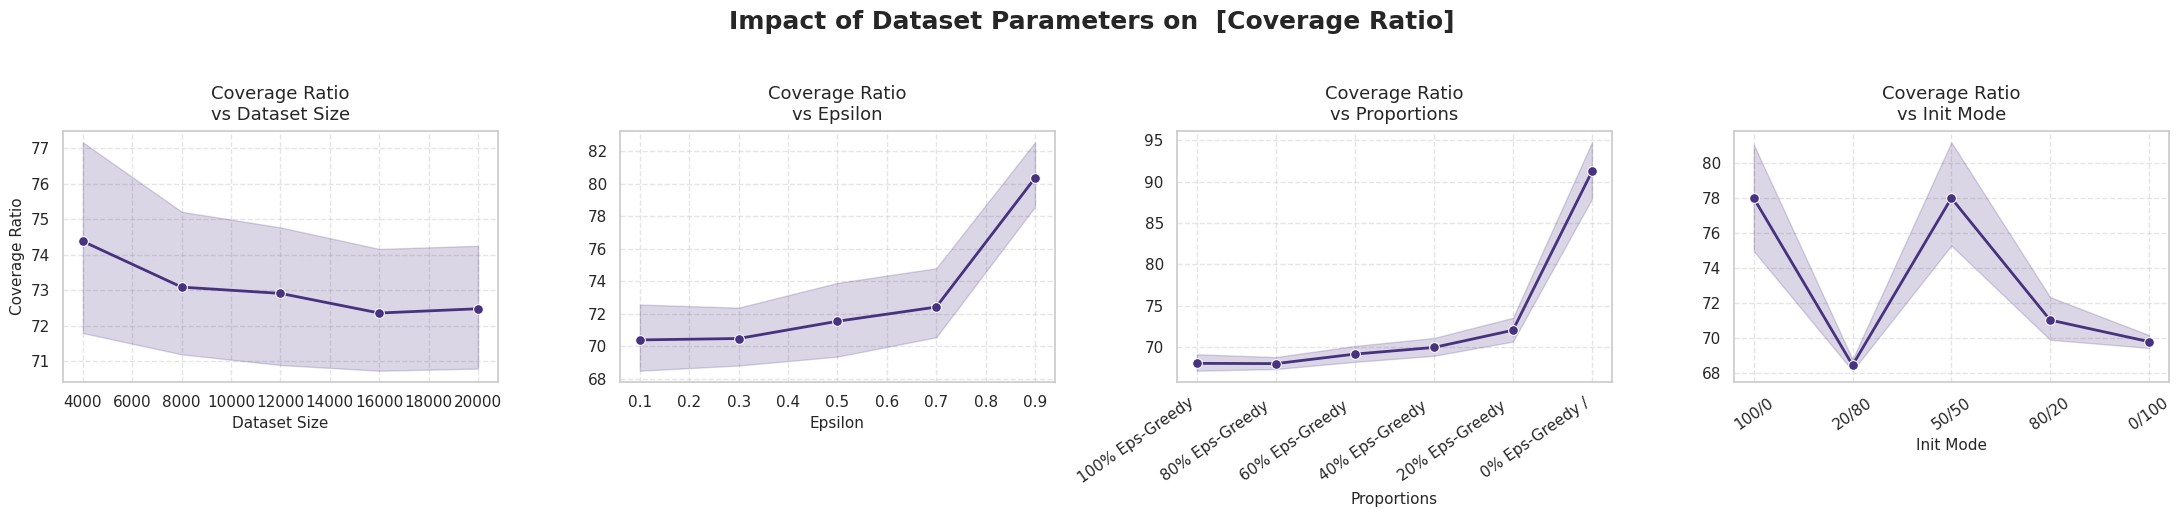

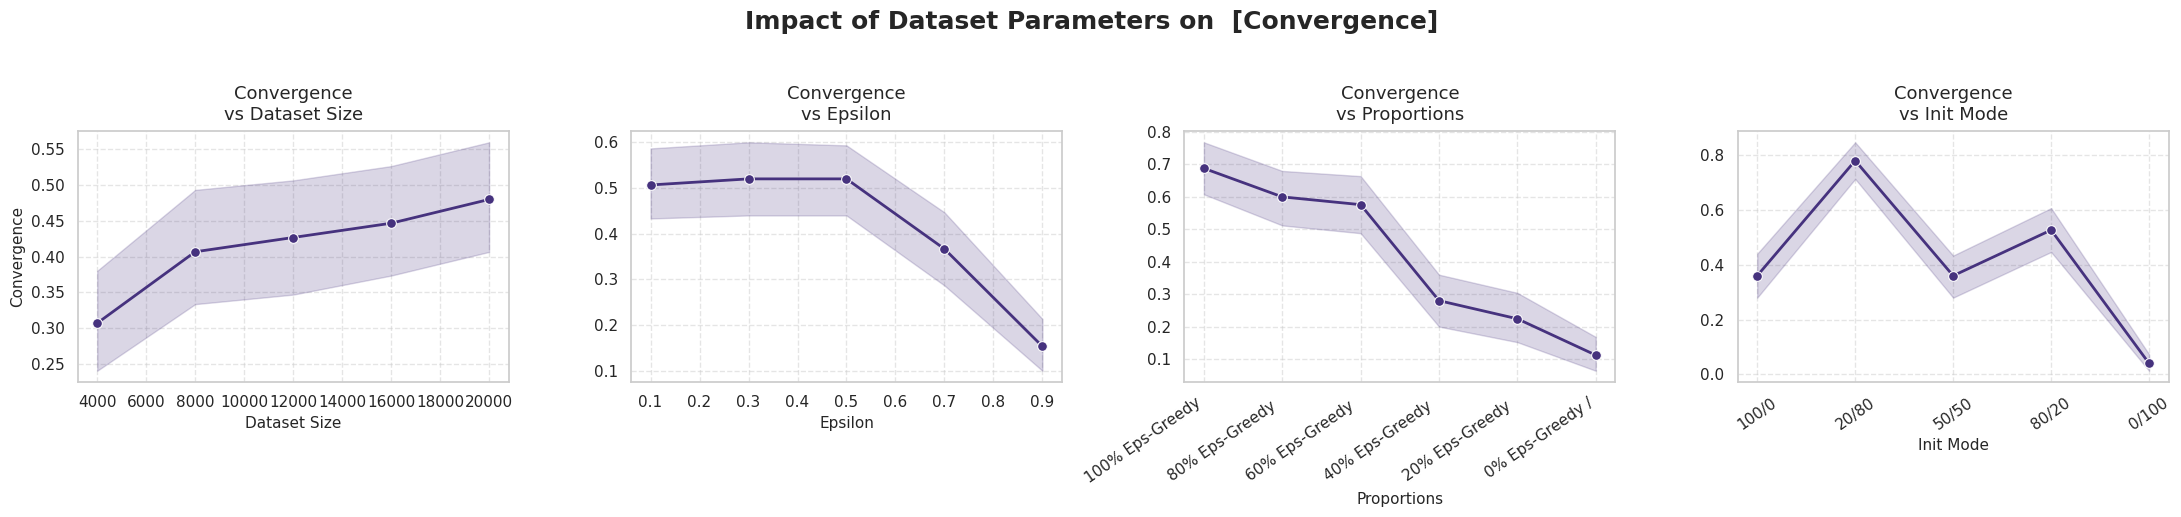

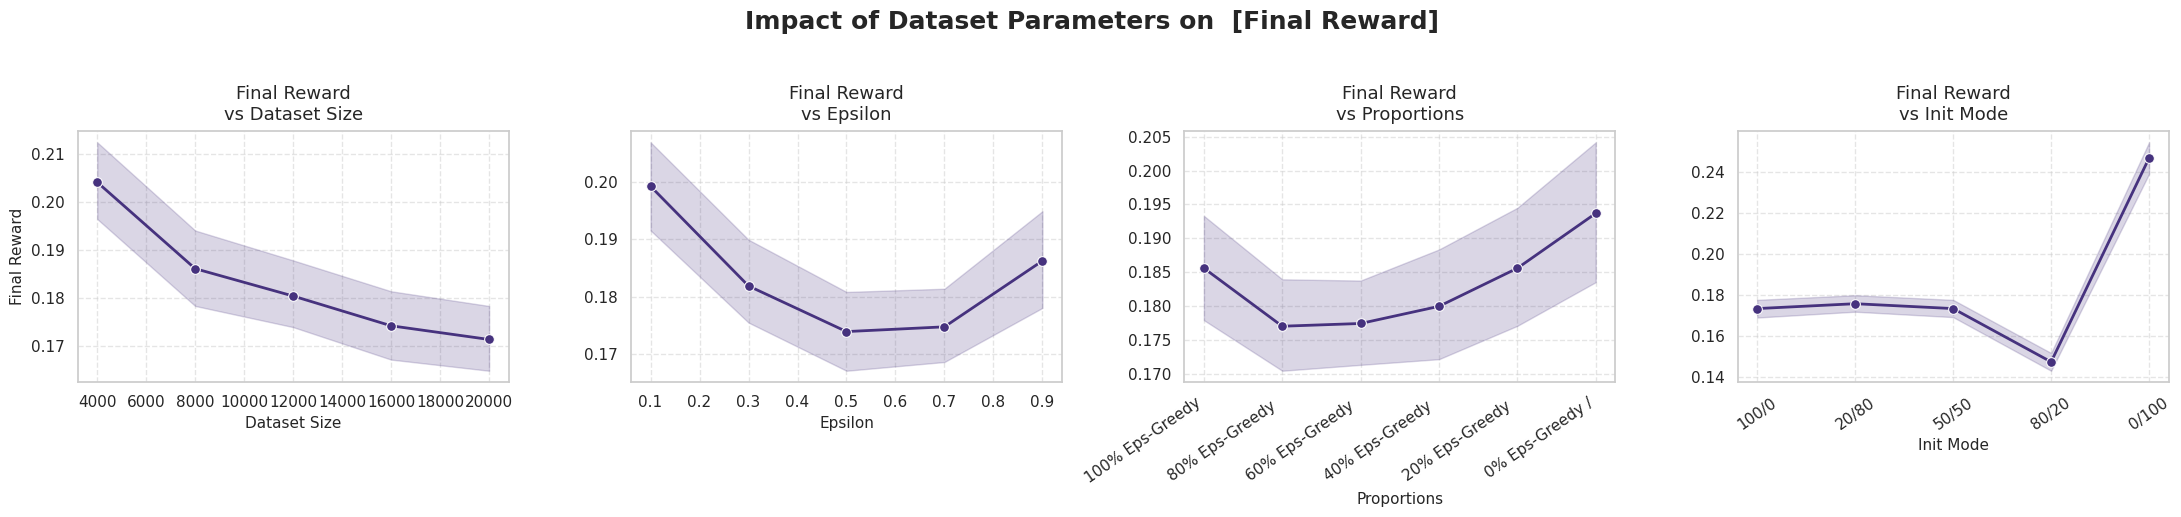

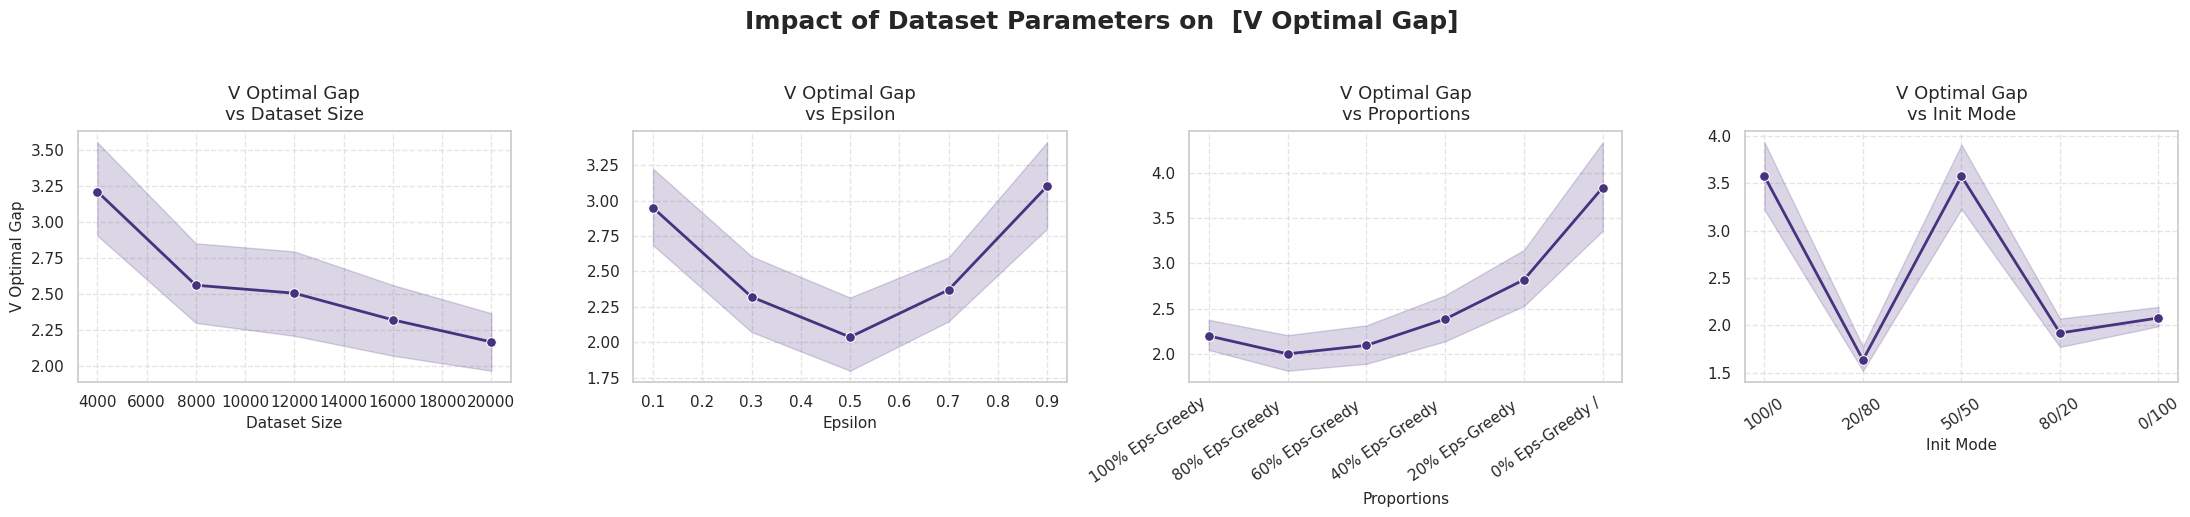

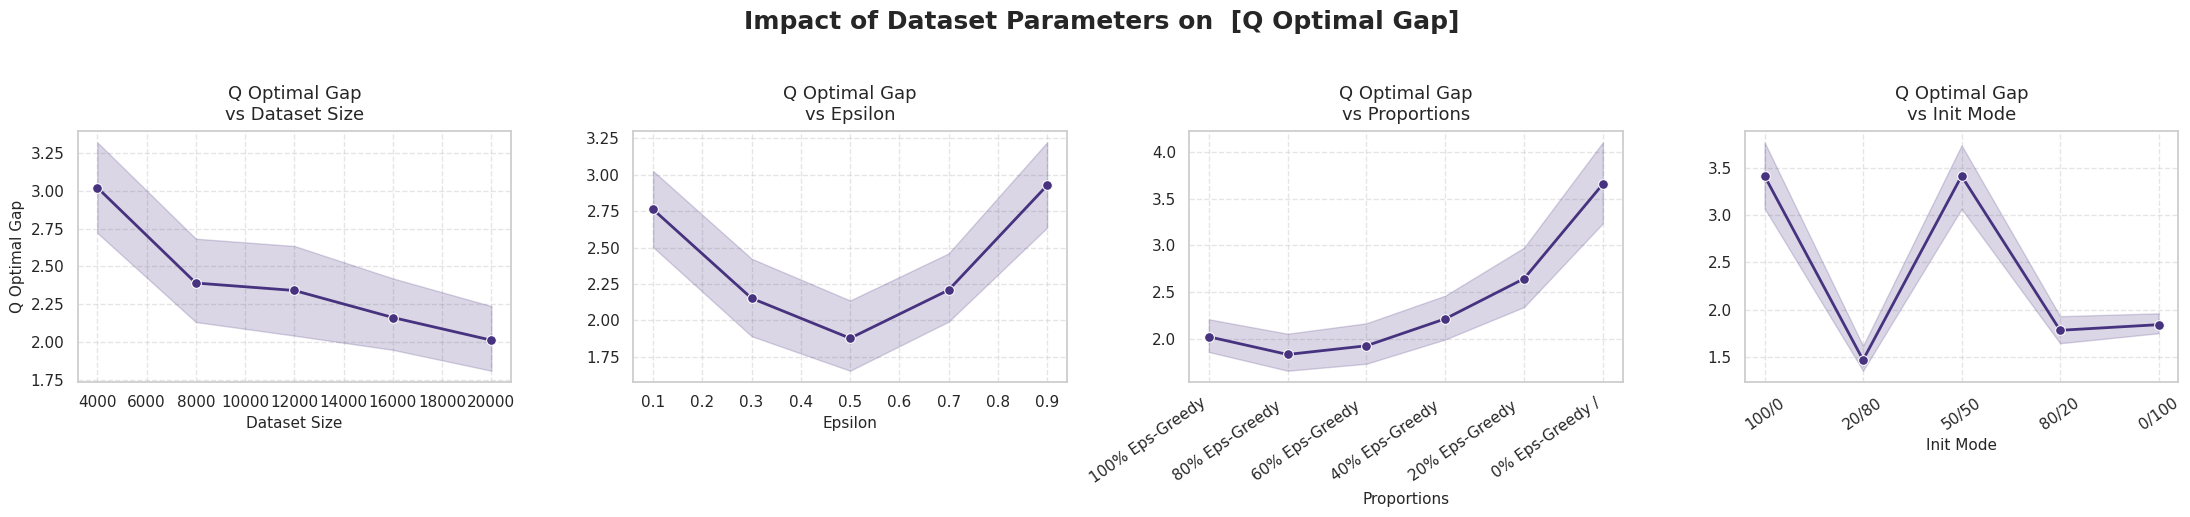

In [5]:
# ── Performance Analysis Plots ────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.dpi'] = 100

x_vars = ["Dataset Size", "Epsilon", "Proportions", "Init Mode"]
y_vars = ["Coverage Ratio", "Convergence", "Final Reward", "V Optimal Gap", "Q Optimal Gap"]

# Columns that need x-tick rotation (categorical)
ROTATE_COLS = {"Proportions", "Init Mode"}

# ── Short-label mapping for Proportions ───────────────────────────────────────
def shorten_proportion_label(label):
    """Convert e.g. '[(opt,0.3,rand,0.7)]' → 'opt30/rnd70'."""
    import re
    parts = re.findall(r"'?(\w+)'?\s*[,:]\s*([\d.]+)", str(label))
    if parts:
        return "/".join(
            f"{name[:3]}{int(float(ratio)*100)}"
            for name, ratio in parts
        )
    return str(label)[:15]

print("📊 Generating Performance Analysis Plots...")

for y_var in y_vars:
    if y_var not in df_results.columns:
        print(f"⚠️  Warning: '{y_var}' not found in results — skipping.")
        continue

    fig, axes = plt.subplots(1, len(x_vars), figsize=(22, 5))
    fig.suptitle(f'Impact of Dataset Parameters on  [{y_var}]',
                 fontsize=18, fontweight='bold', y=1.03)

    for i, x_var in enumerate(x_vars):
        ax = axes[i]
        if x_var not in df_results.columns:
            ax.set_visible(False)
            continue

        sns.lineplot(
            data=df_results,
            x=x_var,
            y=y_var,
            marker='o',
            markersize=7,
            linewidth=2,
            err_style="band",
            ax=ax,
        )

        ax.set_title(f'{y_var}\nvs {x_var}', fontsize=13, pad=8)
        ax.set_xlabel(x_var, fontsize=11)
        ax.set_ylabel(y_var if i == 0 else "", fontsize=11)
        ax.grid(True, linestyle="--", alpha=0.5)

        if x_var in ROTATE_COLS:
            ax.tick_params(axis='x', rotation=35)

        # ── Shorten Proportions tick labels ───────────────────────────────
        if x_var == "Proportions":
            ax.set_xticks(ax.get_xticks())                  # fix locator first
            ax.set_xticklabels(
                [shorten_proportion_label(t.get_text()) for t in ax.get_xticklabels()],
                rotation=35, ha='right'
            )

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_1816603/3963854072.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


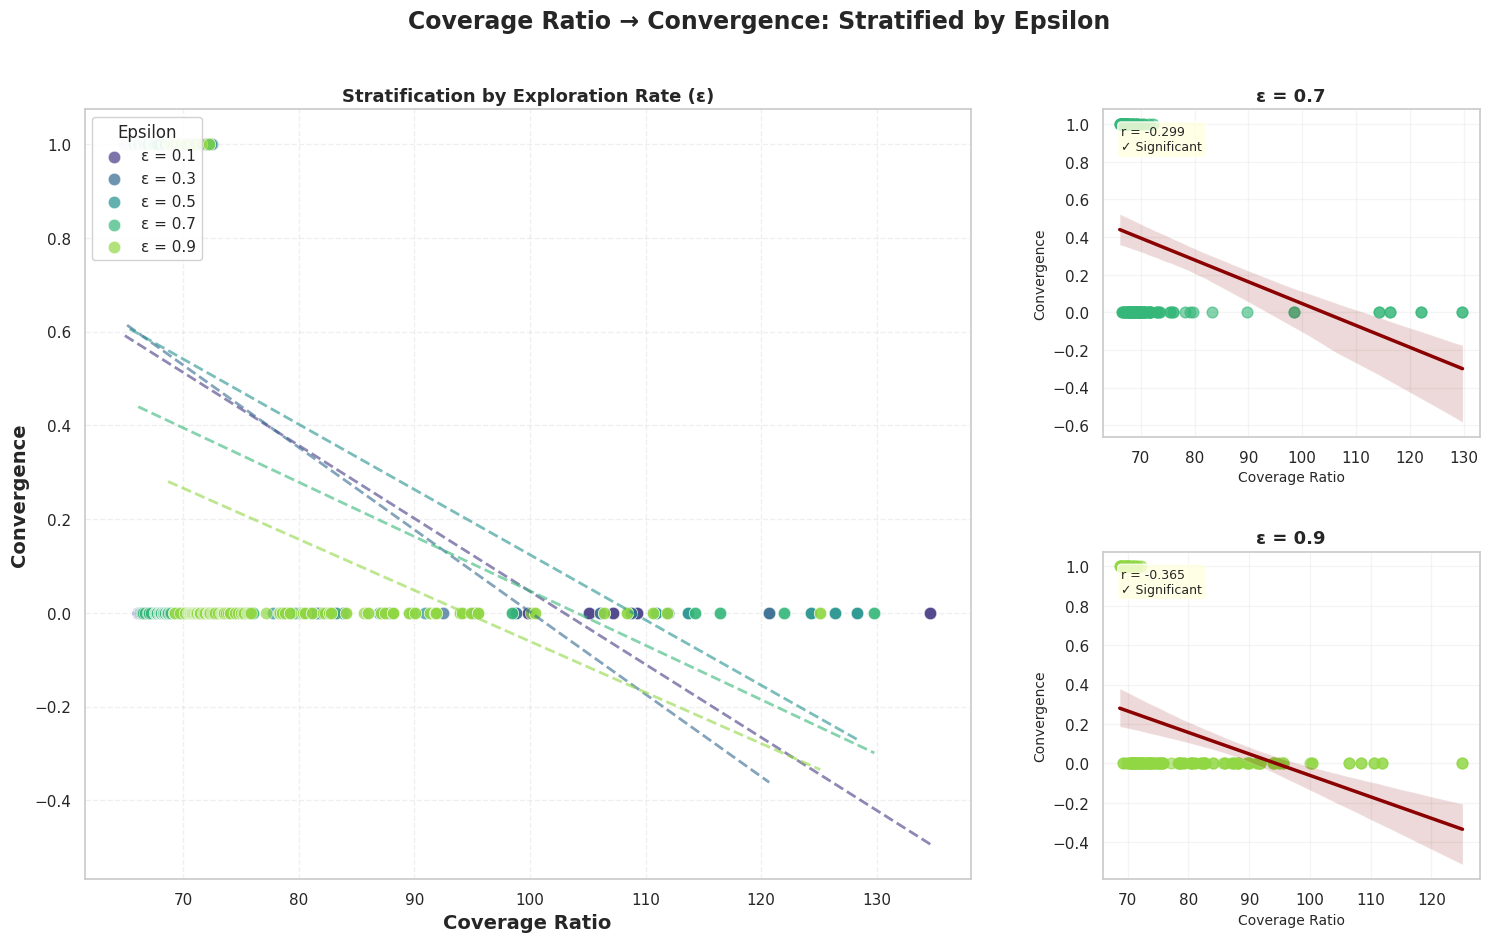

📊  COVERAGE RATIO → CONVERGENCE  |  Pearson r by Epsilon
-----------------------------------------------------------------
  ε = 0.1:  r = -0.372  |  p = 0.0000  ✓
  ε = 0.3:  r = -0.393  |  p = 0.0000  ✓
  ε = 0.5:  r = -0.384  |  p = 0.0000  ✓
  ε = 0.7:  r = -0.299  |  p = 0.0002  ✓
  ε = 0.9:  r = -0.365  |  p = 0.0000  ✓


In [7]:
from scipy.stats import pearsonr
import numpy as np

# ── Coverage Ratio → Convergence Analysis ─────────────────────────────────────
df_plot = df_results[['Coverage Ratio', 'Convergence', 'Epsilon']].dropna()

epsilon_values = sorted(df_plot['Epsilon'].unique())
colors         = sns.color_palette("viridis", n_colors=len(epsilon_values))
epsilon_colors = {eps: colors[i] for i, eps in enumerate(epsilon_values)}
eps_highlight  = epsilon_values[-2:]   # two highest ε for right panels

fig = plt.figure(figsize=(18, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.35)
fig.suptitle('Coverage Ratio → Convergence: Stratified by Epsilon',
             fontsize=17, fontweight='bold', y=0.98)

# ── Main scatter ───────────────────────────────────────────────────────────────
ax_main = fig.add_subplot(gs[:, 0:2])

for eps_val in epsilon_values:
    subset = df_plot[df_plot['Epsilon'] == eps_val].sort_values('Coverage Ratio')
    ax_main.scatter(subset['Coverage Ratio'], subset['Convergence'],
                    label=f'ε = {eps_val}', alpha=0.7, s=80,
                    color=epsilon_colors[eps_val], edgecolors='white', linewidth=0.5)

    if len(subset) > 2:
        z = np.polyfit(subset['Coverage Ratio'], subset['Convergence'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(subset['Coverage Ratio'].min(), subset['Coverage Ratio'].max(), 100)
        ax_main.plot(x_line, p(x_line), '--',
                     color=epsilon_colors[eps_val], alpha=0.6, linewidth=2)

ax_main.set_xlabel('Coverage Ratio', fontsize=14, fontweight='bold')
ax_main.set_ylabel('Convergence',    fontsize=14, fontweight='bold')
ax_main.set_title('Stratification by Exploration Rate (ε)', fontsize=13, fontweight='bold')
ax_main.legend(title='Epsilon', loc='upper left', fontsize=11,
               title_fontsize=12, framealpha=0.9)
ax_main.grid(alpha=0.3, linestyle='--')

# ── Right panels: regression for two highlight epsilons ────────────────────────
for idx, eps_val in enumerate(eps_highlight):
    ax     = fig.add_subplot(gs[idx, 2])
    subset = df_plot[df_plot['Epsilon'] == eps_val]

    sns.regplot(data=subset, x='Coverage Ratio', y='Convergence',
                scatter_kws={'alpha': 0.6, 's': 60, 'color': epsilon_colors[eps_val]},
                line_kws={'color': 'darkred', 'linewidth': 2.5},
                ax=ax)

    corr, p_val = pearsonr(subset['Coverage Ratio'], subset['Convergence'])
    sig = "✓ Significant" if p_val < 0.05 else "Not sig."
    ax.text(0.05, 0.95, f'r = {corr:.3f}\n{sig}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    ax.set_title(f'ε = {eps_val}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Coverage Ratio', fontsize=10)
    ax.set_ylabel('Convergence',    fontsize=10)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# ── Summary stats ──────────────────────────────────────────────────────────────
print("=" * 65)
print("📊  COVERAGE RATIO → CONVERGENCE  |  Pearson r by Epsilon")
print("-" * 65)
for eps_val in epsilon_values:
    subset = df_plot[df_plot['Epsilon'] == eps_val]
    if len(subset) > 2:
        corr, p_val = pearsonr(subset['Coverage Ratio'], subset['Convergence'])
        sig = "✓" if p_val < 0.05 else "✗"
        print(f"  ε = {eps_val}:  r = {corr:6.3f}  |  p = {p_val:.4f}  {sig}")
print("=" * 65)


## Linear Fitted Q-Iteration

Given an offline batch dataset $\mathcal{D}={(x_i,a_i,r_i,x_i')}_{i=1}^n$, this version of (linear) FQI does:

1. **Build targets using current Q estimate**
   $$
   y_i^{(k)} = r_i + \gamma \max_{a'} Q_{\theta_k}(x'_i, a')
   $$

2. **Fit a new Q-function to those targets** by regression on $(x_i,a_i)$
   $$
   \theta_{k+1}^{+}
   = \arg\min_\theta \sum_{i=1}^n \left(y_i^{(k)} - \phi(x_i,a_i)^\top\theta\right)^2 + \lambda|\theta|_2^2
   $$

3. (Optional) **soft update**:
   $$
   \theta_{k+1} = \tau,\theta_k + (1-\tau),\theta_{k+1}^{+}
   $$

LEt's try first with the dataset of FOGAS:

In [3]:
# Initialize FQI Solver
solver_fqi = FQISolver(
    mdp=mdp,
    csv_path=str(DATASET_PATH),
    device=device,
    seed=seed,
    ridge=1e-2 
)
evaluator_fqi = FQIEvaluator(solver_fqi)

In [4]:
pi_fqi = solver_fqi.run(
    K=1000, 
    tau=0.1, 
    verbose=True
)
print("\nFQI Policy:")
evaluator_fqi.print_policy()
evaluator_fqi.compare_final_rewards()
evaluator_fqi.print_optimal_path(max_steps=30)

FQI: 100%|█████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1602.10it/s, theta_norm=3.8244]



FQI Policy:

========== LEARNED POLICY (FQI) ==========
  State 0: π(a=0|s=0) = 0.00  π(a=1|s=0) = 1.00  π(a=2|s=0) = 0.00  π(a=3|s=0) = 0.00  --> best action: 1
  State 1: π(a=0|s=1) = 0.00  π(a=1|s=1) = 0.00  π(a=2|s=1) = 1.00  π(a=3|s=1) = 0.00  --> best action: 2
  State 2: π(a=0|s=2) = 0.00  π(a=1|s=2) = 0.00  π(a=2|s=2) = 0.00  π(a=3|s=2) = 1.00  --> best action: 3
  State 3: π(a=0|s=3) = 0.00  π(a=1|s=3) = 1.00  π(a=2|s=3) = 0.00  π(a=3|s=3) = 0.00  --> best action: 1
  State 4: π(a=0|s=4) = 1.00  π(a=1|s=4) = 0.00  π(a=2|s=4) = 0.00  π(a=3|s=4) = 0.00  --> best action: 0
  State 5: π(a=0|s=5) = 0.00  π(a=1|s=5) = 1.00  π(a=2|s=5) = 0.00  π(a=3|s=5) = 0.00  --> best action: 1
  State 6: π(a=0|s=6) = 0.00  π(a=1|s=6) = 1.00  π(a=2|s=6) = 0.00  π(a=3|s=6) = 0.00  --> best action: 1
  State 7: π(a=0|s=7) = 0.00  π(a=1|s=7) = 0.00  π(a=2|s=7) = 0.00  π(a=3|s=7) = 1.00  --> best action: 3
  State 8: π(a=0|s=8) = 0.00  π(a=1|s=8) = 1.00  π(a=2|s=8) = 0.00  π(a=3|s=8) = 0.00  --> best

Now lets create a dataset with full coverage:

In [5]:
DATASET_PATH2 = PROJECT_ROOT / "datasets" / "10grid_wall_fqi.csv"

In [5]:
walls = [4, 11, 14, 17, 21, 22, 27, 34, 37, 40, 42, 43, 44, 45, 46, 47, 49, 54, 62, 64, 66, 72, 76, 82, 84, 86, 87, 94]
pits = [18, 32, 57, 61, 75]
goal = [99]

# Configure the probabilities: 
# 80% of trajectories start in a random "safe" state
# 20% of trajectories start in the fixed initial state (x0)
reset_options = {
    'random': 0.8, 
    'x0': 0.2
}

# Initialize the collector with these options
collector = EnvDataCollector(
    mdp=mdp,
    env_name="10grid_wall",
    restricted_states=walls,  # These will never be starting states
    terminal_states=pits + goal, # Terminal states are also excluded
    reset_probs=reset_options,
    max_steps=50
)
DATASET_PATH2 = PROJECT_ROOT / "datasets" / "10grid_wall_fqi.csv"

collector.collect_dataset_terminal_aware(
    n_steps=20000, extra_steps=5, save_path=str(DATASET_PATH2), verbose=True
)

✅ Terminal-aware dataset saved to: /shared/home/mauro.diaz/work/FOGAS/datasets/10grid_wall_fqi.csv
   Total transitions: 20000


,episode,step,state,action,reward,next_state
0,0,0,3,0,-0.1,3
1,0,1,3,3,-0.1,3
2,0,2,3,2,-0.1,2
3,0,3,2,1,-0.1,12
4,0,4,12,1,-0.1,12
...,...,...,...,...,...,...
19995,627,44,41,0,-0.1,31
19996,627,45,31,0,-0.1,31
19997,627,46,31,1,-0.1,41
19998,627,47,41,1,-0.1,51


In [6]:
# Initialize FQI Solver
solver_fqi = FQISolver(
    mdp=mdp,
    csv_path=str(DATASET_PATH2),
    device=device,
    seed=seed,
    ridge=1e-2 
)
evaluator_fqi = FQIEvaluator(solver_fqi)
pi_fqi = solver_fqi.run(
    K=5000, 
    tau=0.1, 
    verbose=True
)
print("\nFQI Policy:")
evaluator_fqi.print_policy()
evaluator_fqi.compare_final_rewards()
evaluator_fqi.print_optimal_path(max_steps=24)

FQI: 100%|██████████| 5000/5000 [04:16<00:00, 19.48it/s, theta_norm=285.0963]


FQI Policy:

========== LEARNED POLICY (FQI) ==========
  State 0: π(a=0|s=0) = 0.00  π(a=1|s=0) = 0.00  π(a=2|s=0) = 0.00  π(a=3|s=0) = 1.00  --> best action: 3
  State 1: π(a=0|s=1) = 0.00  π(a=1|s=1) = 0.00  π(a=2|s=1) = 0.00  π(a=3|s=1) = 1.00  --> best action: 3
  State 2: π(a=0|s=2) = 0.00  π(a=1|s=2) = 0.00  π(a=2|s=2) = 0.00  π(a=3|s=2) = 1.00  --> best action: 3
  State 3: π(a=0|s=3) = 0.00  π(a=1|s=3) = 1.00  π(a=2|s=3) = 0.00  π(a=3|s=3) = 0.00  --> best action: 1
  State 4: π(a=0|s=4) = 1.00  π(a=1|s=4) = 0.00  π(a=2|s=4) = 0.00  π(a=3|s=4) = 0.00  --> best action: 0
  State 5: π(a=0|s=5) = 0.00  π(a=1|s=5) = 0.00  π(a=2|s=5) = 0.00  π(a=3|s=5) = 1.00  --> best action: 3
  State 6: π(a=0|s=6) = 0.00  π(a=1|s=6) = 0.00  π(a=2|s=6) = 0.00  π(a=3|s=6) = 1.00  --> best action: 3
  State 7: π(a=0|s=7) = 0.00  π(a=1|s=7) = 0.00  π(a=2|s=7) = 0.00  π(a=3|s=7) = 1.00  --> best action: 3
  State 8: π(a=0|s=8) = 0.00  π(a=1|s=8) = 0.00  π(a=2|s=8) = 0.00  π(a=3|s=8) = 1.00  --> best

### GRID-SEARCH FQI

In [3]:
# ── Load Results ──────────────────────────────────────────────────────────────
CSV_NAME = "grid_search_results_sbatch_fqi.csv"
RESULTS_PATH = Path("/shared/home/mauro.diaz/work/FOGAS") / CSV_NAME
df_results = pd.read_csv(RESULTS_PATH)

print(f"✅ Loaded {len(df_results)} rows from '{RESULTS_PATH}'")
df_results.head()

✅ Loaded 1500 rows from '/shared/home/mauro.diaz/work/FOGAS/grid_search_results_sbatch_fqi.csv'


,Dataset Size,Epsilon,Proportions,Init Mode,Extra Steps,Coverage Ratio,Log Coverage,Convergence,Final Reward,V Optimal Gap,Q Optimal Gap
0,4000,0.1,100% Eps-Greedy,100/0,0,64.945532,1.812549,0,-0.1,6.242475,6.154732
1,8000,0.1,100% Eps-Greedy,100/0,0,64.951071,1.812586,0,-0.1,5.759937,5.672194
2,12000,0.1,100% Eps-Greedy,100/0,0,64.957092,1.812627,0,-0.1,5.964807,5.877064
3,16000,0.1,100% Eps-Greedy,100/0,0,64.960877,1.812652,0,-0.1,5.877064,5.789321
4,20000,0.1,100% Eps-Greedy,100/0,0,64.964368,1.812675,0,-0.1,6.154732,6.066989


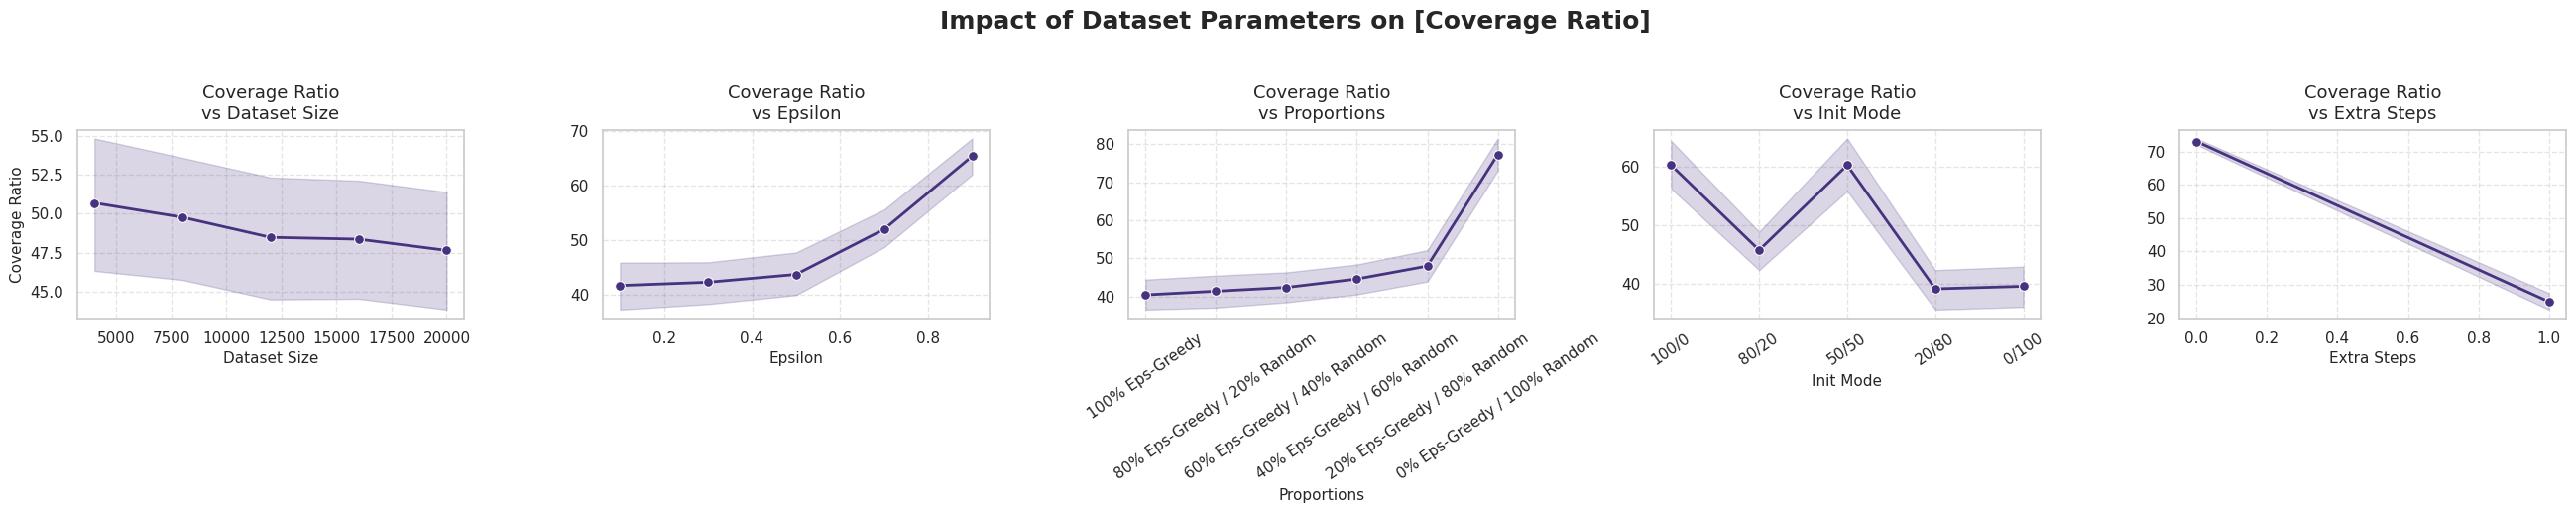

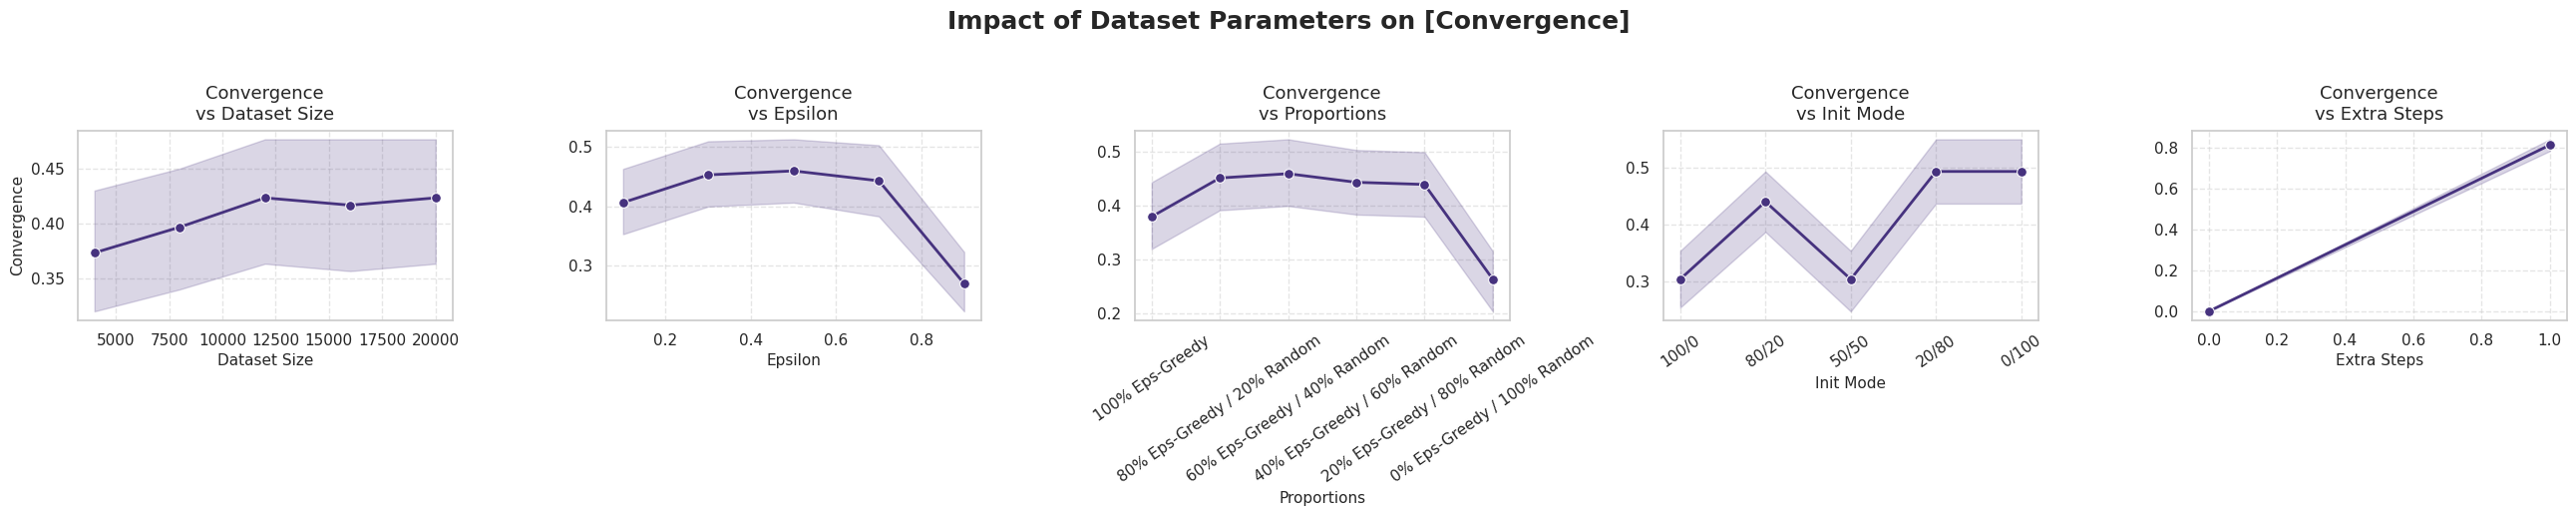

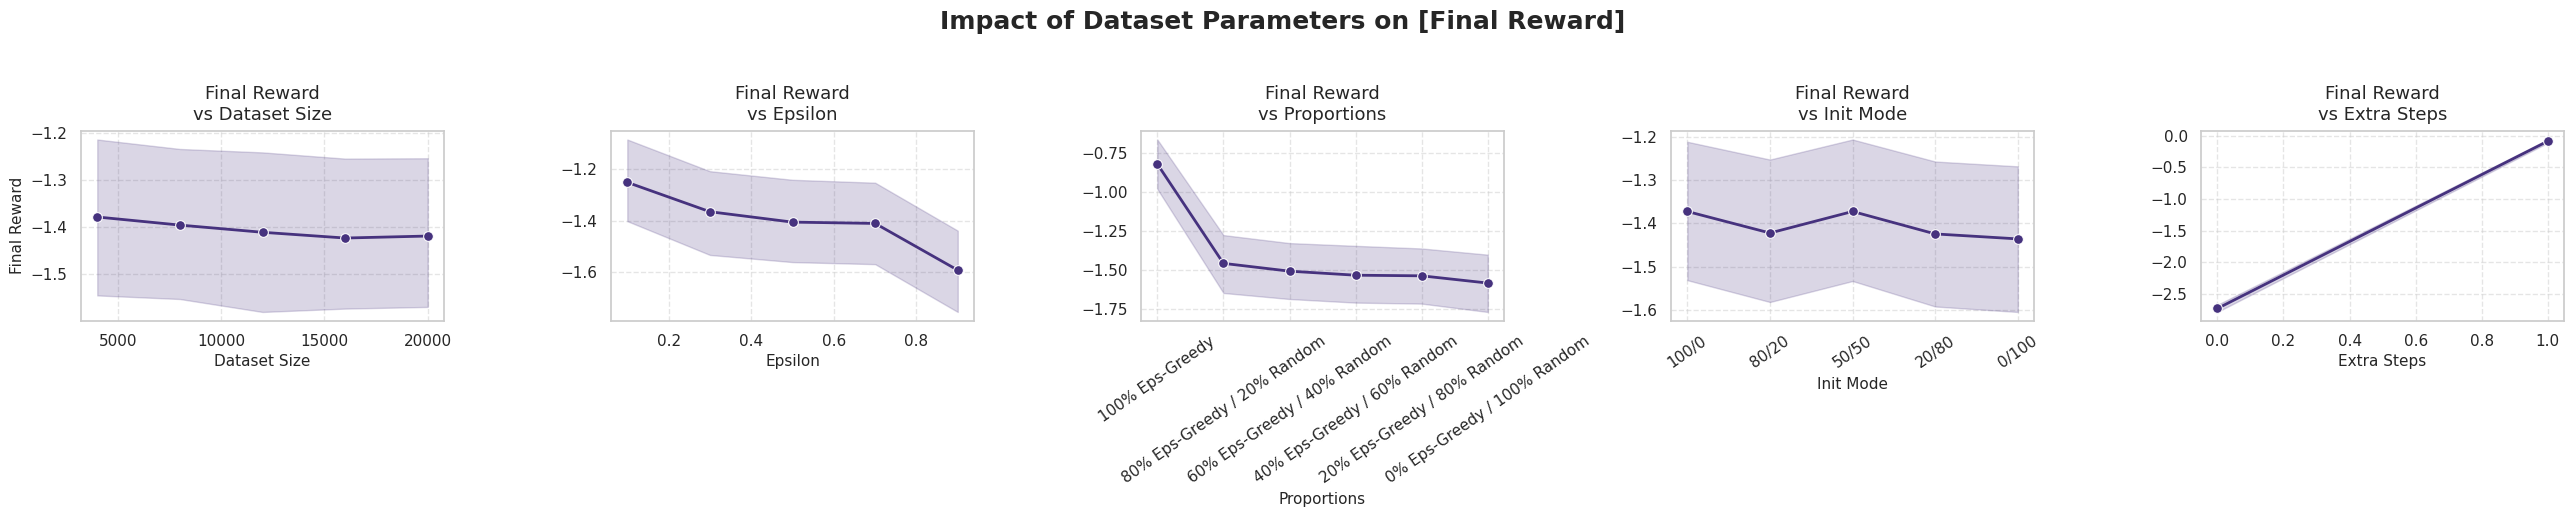

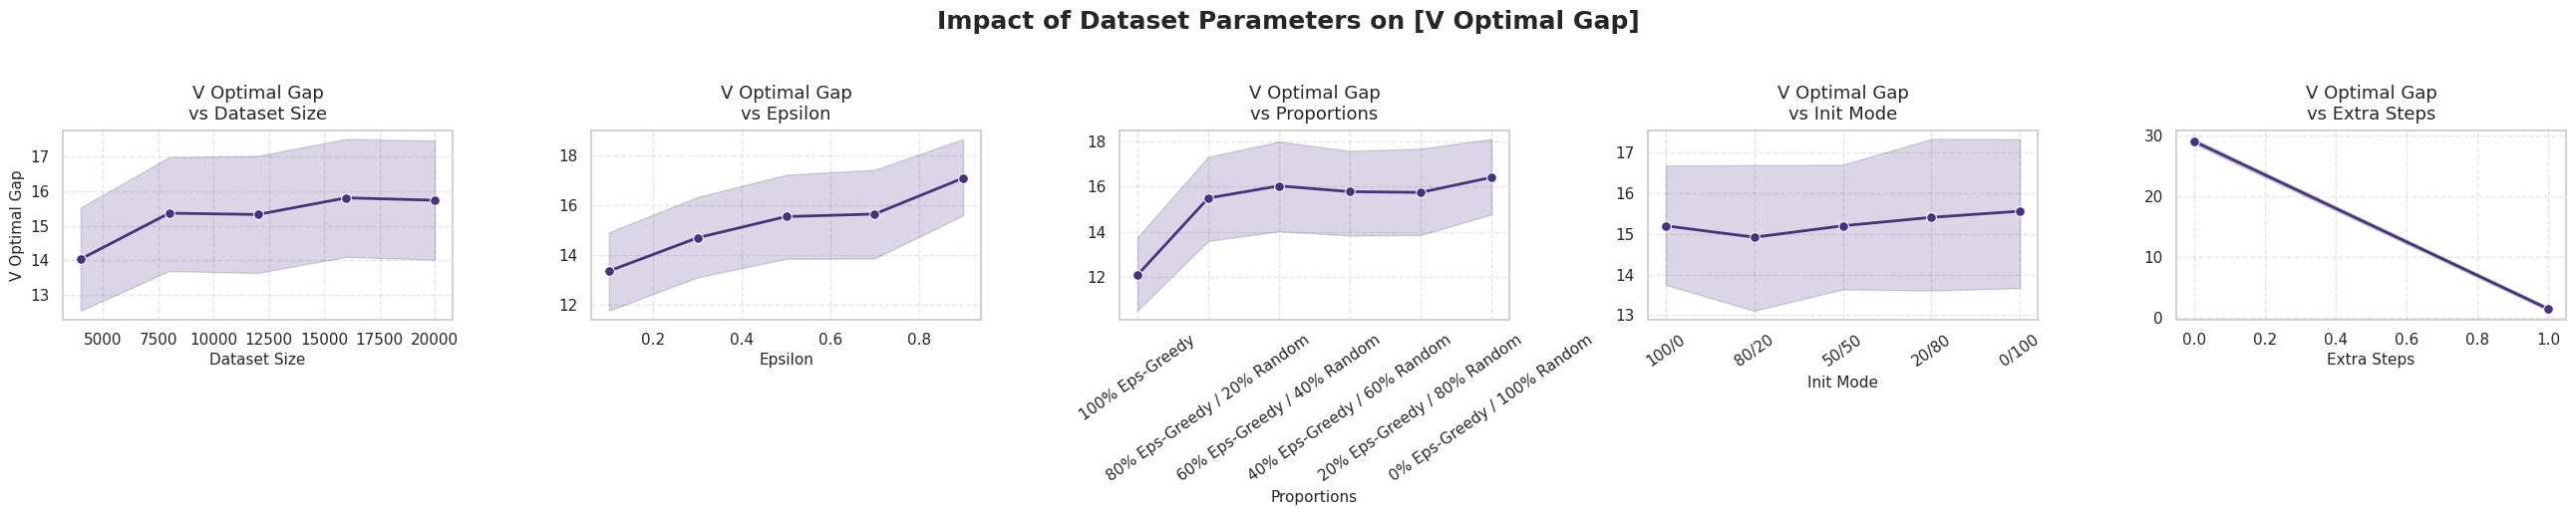

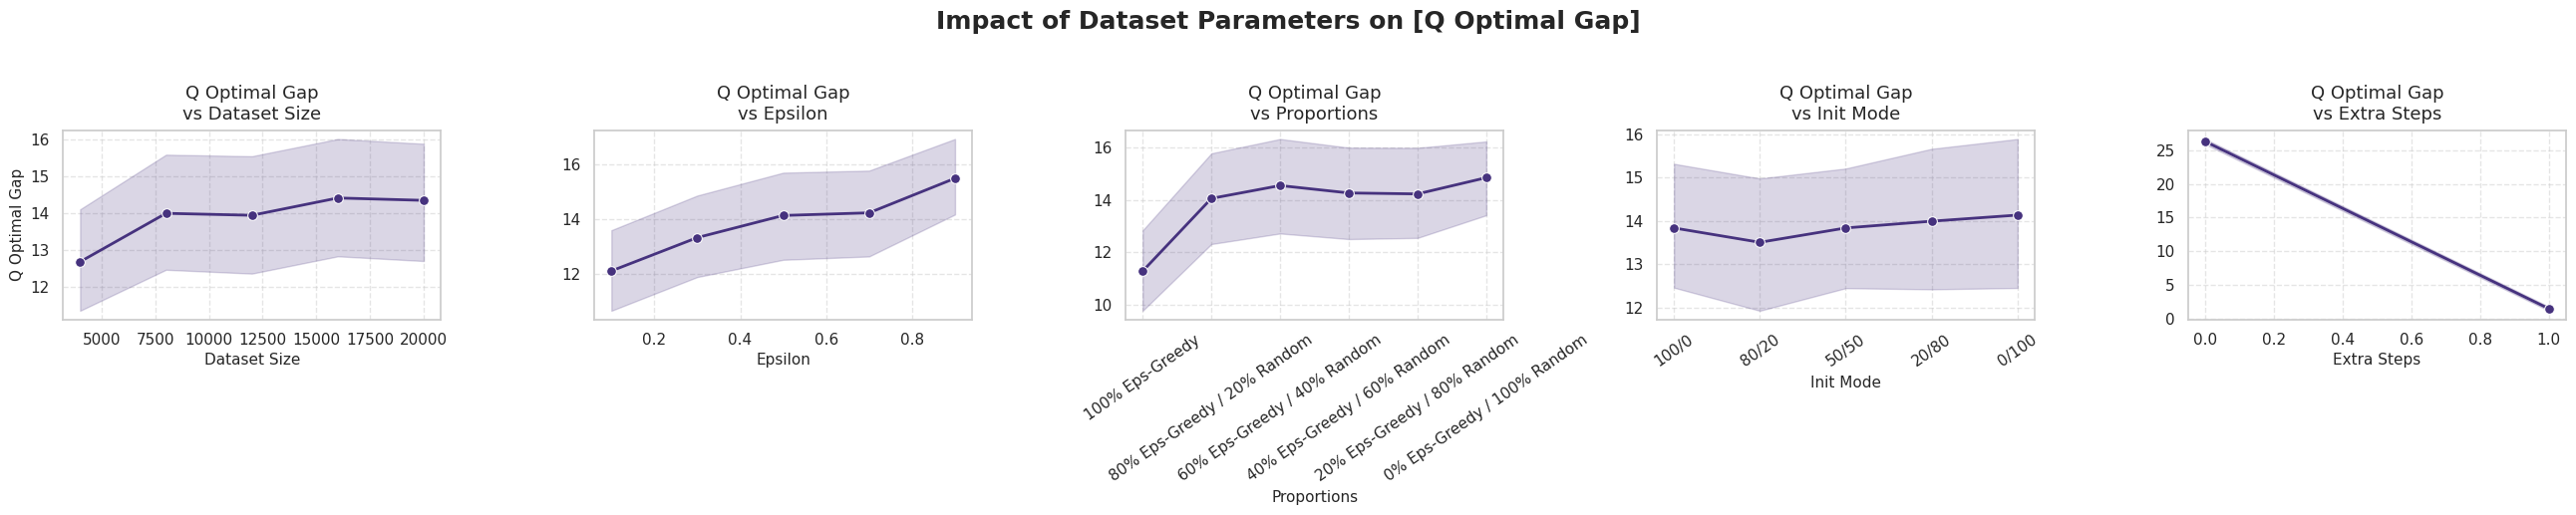

In [4]:
# ── Performance Analysis Plots ────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.dpi'] = 100

x_vars = ["Dataset Size", "Epsilon", "Proportions", "Init Mode", "Extra Steps"] 
y_vars = ["Coverage Ratio", "Convergence", "Final Reward", "V Optimal Gap", "Q Optimal Gap"]

ROTATE_COLS = {"Proportions", "Init Mode"}

for y_var in y_vars:
    if y_var not in df_results.columns:
        print(f"⚠️  Warning: '{y_var}' not found — skipping.")
        continue

    fig, axes = plt.subplots(1, len(x_vars), figsize=(26, 5))  # wider for 5 plots
    fig.suptitle(f'Impact of Dataset Parameters on [{y_var}]',
                 fontsize=18, fontweight='bold', y=1.03)

    for i, x_var in enumerate(x_vars):
        ax = axes[i]
        if x_var not in df_results.columns:
            ax.set_visible(False)
            continue

        sns.lineplot(
            data=df_results, x=x_var, y=y_var,
            marker='o', markersize=7, linewidth=2,
            err_style="band", ax=ax,
        )
        ax.set_title(f'{y_var}\nvs {x_var}', fontsize=13, pad=8)
        ax.set_xlabel(x_var, fontsize=11)
        ax.set_ylabel(y_var if i == 0 else "", fontsize=11)
        ax.grid(True, linestyle="--", alpha=0.5)
        if x_var in ROTATE_COLS:
            ax.tick_params(axis='x', rotation=35)

    plt.tight_layout()
    plt.show()


## Final comparation

/tmp/ipykernel_1523717/1240774105.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


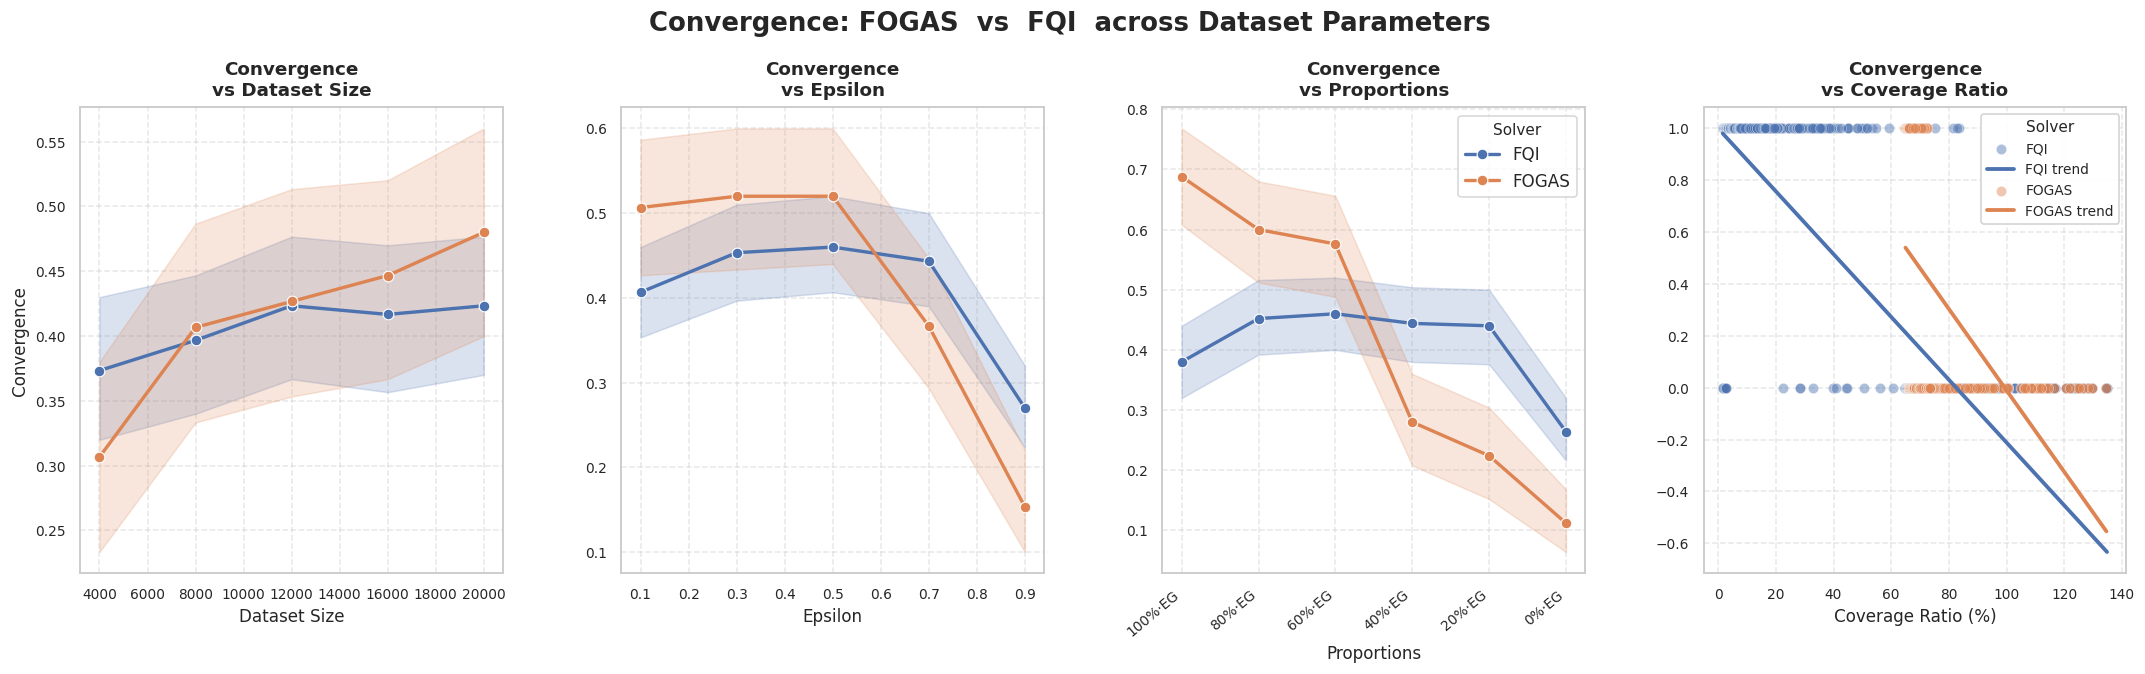

In [5]:
df_results['Solver']   = 'FQI'
CSV_NAME2 = "grid_search_results_sbatch.csv"          # ← change to _rbf.csv for RBF
# The script saves the CSV in the CWD where sbatch runs (FOGAS root)
RESULTS_PATH2 = Path("/shared/home/mauro.diaz/work/FOGAS") / CSV_NAME2
df_fogas = pd.read_csv(RESULTS_PATH2)
df_fogas['Solver'] = 'FOGAS'

df_combined = pd.concat([df_results, df_fogas], ignore_index=True)

# ── Convergence: FOGAS vs FQI ─────────────────────────────────────────────────
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

SOLVER_PALETTE = {"FQI": "#4C72B0", "FOGAS": "#DD8452"}
ROTATE_COLS    = {"Proportions"}

# ── Normalize Coverage Ratio to same scale (0–100%) ───────────────────────────
df_combined_plot = df_combined.copy()
fogas_mask = df_combined_plot['Solver'] == 'FOGAS'
cr = df_combined_plot.loc[fogas_mask, 'Coverage Ratio']
if cr.max() <= 1.0:   # FOGAS is 0–1, FQI is 0–100
    df_combined_plot.loc[fogas_mask, 'Coverage Ratio'] *= 100

# ── Proportion label shortener ─────────────────────────────────────────────────
def shorten_proportion_label(label):
    import re
    s = str(label)
    # "100% Eps-Greedy" → "100% EG"
    m = re.match(r'(\d+)%\s*Eps.Greedy', s)
    if m:
        return f"{m.group(1)}%·EG"
    # dict-style "(opt, 0.3)" → "opt30"
    parts = re.findall(r"'?(\w+)'?\s*[,:]\s*([\d.]+)", s)
    if parts:
        return "/".join(f"{n[:3]}{int(float(r)*100)}" for n, r in parts)
    return s[:12]

x_vars = ["Dataset Size", "Epsilon", "Proportions", "Coverage Ratio"]

fig, axes = plt.subplots(1, len(x_vars), figsize=(24, 5.5),
                         gridspec_kw={'wspace': 0.28})
fig.suptitle('Convergence: FOGAS  vs  FQI  across Dataset Parameters',
             fontsize=17, fontweight='bold', y=1.04)

for i, x_var in enumerate(x_vars):
    ax = axes[i]

    if x_var not in df_combined_plot.columns:
        ax.set_visible(False)
        continue

    if x_var == "Coverage Ratio":
        # ── Scatter + trend line per solver ───────────────────────────────
        for solver, color in SOLVER_PALETTE.items():
            sub = df_combined_plot[df_combined_plot['Solver'] == solver] \
                      .dropna(subset=['Coverage Ratio', 'Convergence'])
            ax.scatter(sub['Coverage Ratio'], sub['Convergence'],
                       alpha=0.45, s=45, color=color, label=solver,
                       edgecolors='white', linewidth=0.4)
            if len(sub) > 2:
                z = np.polyfit(sub['Coverage Ratio'], sub['Convergence'], 1)
                p = np.poly1d(z)
                x_line = np.linspace(sub['Coverage Ratio'].min(),
                                     sub['Coverage Ratio'].max(), 100)
                ax.plot(x_line, p(x_line), color=color, linewidth=2.5,
                        label=f'{solver} trend')
        ax.legend(title='Solver', fontsize=9, title_fontsize=10,
                  framealpha=0.9, loc='best')
        ax.set_xlabel('Coverage Ratio (%)', fontsize=11)

    else:
        # ── Line plot ─────────────────────────────────────────────────────
        sns.lineplot(
            data=df_combined_plot,
            x=x_var, y='Convergence',
            hue='Solver', palette=SOLVER_PALETTE,
            marker='o', markersize=7, linewidth=2.2,
            err_style="band", ax=ax,
        )
        ax.set_xlabel(x_var, fontsize=11)

        # Legend: only on last lineplot
        legend = ax.get_legend()
        if i < len(x_vars) - 2:   # hide all but the one before Coverage Ratio
            if legend: legend.remove()
        else:
            if legend:
                legend.set_title('Solver')
                legend.get_title().set_fontsize(10)

        if x_var in ROTATE_COLS:
            ax.tick_params(axis='x', rotation=40)

        if x_var == "Proportions":
            ax.set_xticks(ax.get_xticks())
            ax.set_xticklabels(
                [shorten_proportion_label(t.get_text())
                 for t in ax.get_xticklabels()],
                rotation=40, ha='right', fontsize=9
            )

    ax.set_title(f'Convergence\nvs {x_var}', fontsize=12, pad=8, fontweight='bold')
    ax.set_ylabel('Convergence' if i == 0 else '', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.45)
    ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()
plt.show()